In [1]:
import tonic
import tonic.transforms as transforms  # Not to be mistaken with torchdata.transfroms
from tonic import DiskCachedDataset

# torch imports
import torch
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn


# snntorch imports
import snntorch as snn
from snntorch import surrogate
import snntorch.spikeplot as splt
from snntorch import functional as SF
from snntorch import utils


# other imports
import matplotlib.pyplot as plt
from IPython.display import HTML
from IPython.display import display
import numpy as np
import torchdata
import os
from ipywidgets import IntProgress
import time
import statistics

## Helper func.
def print_frame(transformed_events):
    """Prints a text-based representation of the event frames."""
    # transformed_events is usually a (Time, Channel/Polarity, X, Y) tensor
    # We take the first frame for visualization
    frame = transformed_events[0] 
    print("----------------------------")
    print(frame)


root = "/home/emre/Downloads/"  # similar to os.path.join('content', 'drive', 'My Drive')
os.listdir(os.path.join(root, 'STMNIST')) # confirm the file exists


dataset = tonic.prototype.datasets.STMNIST(root=root, keep_compressed = False, shuffle = False)


events, target = next(iter(dataset))
print(events[0])
print(target)


sensor_size = tuple(tonic.prototype.datasets.STMNIST.sensor_size.values())  # The sensor size for STMNIST is (10, 10, 2)

# filter noisy pixels and integrate events into 1ms frames
frame_transform = transforms.Compose([transforms.Denoise(filter_time=10000),
                                      transforms.ToFrame(sensor_size=sensor_size,
                                                         time_window=20000)
                                     ])

transformed_events = frame_transform(events)

#print_frame(transformed_events)


# events, target = next(iter(dataset))


##### DISPLAY ####

# frame_transform_tonic_visual = tonic.transforms.ToFrame(
#     sensor_size=(10, 10, 2),
#     time_window=10000,
# )

# frames = frame_transform_tonic_visual(events)
# frames = frames / np.max(frames)
# frames = np.rot90(frames, k=-1, axes=(2, 3))
# frames = np.flip(frames, axis=3)

# # Print out the Target
# print('Animation of ST-MNIST')
# print('The target label is:',target)
# animation = tonic.utils.plot_animation(frames)

# # Display the animation inline in a Jupyter notebook
# HTML(animation.to_jshtml())



sensor_size = tonic.prototype.datasets.STMNIST.sensor_size
sensor_size = tuple(sensor_size.values())

# Define a transform
frame_transform = transforms.Compose([transforms.ToFrame(sensor_size=sensor_size, time_window=20000)])


def shorter_transform_STMNIST(data, transform):
    short_train_size = 640
    short_test_size = 320

    train_bar = IntProgress(min=0, max=short_train_size)
    test_bar = IntProgress(min=0, max=short_test_size)

    testset = []
    trainset = []

    print('Porting over and transforming the trainset.')
    display(train_bar)
    for _ in range(short_train_size):
        events, target = next(iter(dataset))
        events = transform(events)
        trainset.append((events, target))
        train_bar.value += 1
    print('Porting over and transforming the testset.')
    display(test_bar)
    for _ in range(short_test_size):
        events, target = next(iter(dataset))
        events = transform(events)
        testset.append((events, target))
        test_bar.value += 1

    return (trainset, testset)

start_time = time.time()
trainset, testset = shorter_transform_STMNIST(dataset, frame_transform)
elapsed_time = time.time() - start_time

# Convert elapsed time to minutes, seconds, and milliseconds
minutes, seconds = divmod(elapsed_time, 60)
seconds, milliseconds = divmod(seconds, 1)
milliseconds = round(milliseconds * 1000)

# Print the elapsed time
print(f"Elapsed time: {int(minutes)} minutes, {int(seconds)} seconds, {milliseconds} milliseconds")



# Create a DataLoader
dataloader = DataLoader(trainset, batch_size=32, shuffle=True)


transform = tonic.transforms.Compose([torch.from_numpy])

cached_trainset = DiskCachedDataset(trainset, transform=transform, cache_path='./cache/stmnist/train')

# no augmentations for the testset
cached_testset = DiskCachedDataset(testset, cache_path='./cache/stmnist/test')

batch_size = 32
trainloader = DataLoader(cached_trainset, batch_size=batch_size, collate_fn=tonic.collation.PadTensors(batch_first=False), shuffle=True)
testloader = DataLoader(cached_testset, batch_size=batch_size, collate_fn=tonic.collation.PadTensors(batch_first=False))


# Query the shape of a sample: time x batch x dimensions
data_tensor, targets = next(iter(trainloader))
print(data_tensor.shape)






device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# neuron and simulation parameters
beta = 0.95

# This is the same architecture that was used in the STMNIST Paper
scnn_net = nn.Sequential(
    nn.Conv2d(2, 32, kernel_size=4),
    snn.Leaky(beta=beta, init_hidden=True),
    nn.Conv2d(32, 64, kernel_size=3),
    snn.Leaky(beta=beta, init_hidden=True),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(64 * 2 * 2, 10),  # Increased size of the linear layer
    snn.Leaky(beta=beta, init_hidden=True, output=True)
).to(device)

optimizer = torch.optim.Adam(scnn_net.parameters(), lr=2e-2, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

def forward_pass(net, data):
    spk_rec = []
    utils.reset(net)  # resets hidden states for all LIF neurons in net

    for step in range(data.size(0)):  # data.size(0) = number of time steps

        spk_out, mem_out = net(data[step])
        spk_rec.append(spk_out)

    return torch.stack(spk_rec)

/home/emre/.local/lib/python3.10/site-packages/torchdata/datapipes/__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


(2, 4, 190540, 0)
5
Porting over and transforming the trainset.


IntProgress(value=0, max=640)

Porting over and transforming the testset.


IntProgress(value=0, max=320)

Elapsed time: 0 minutes, 35 seconds, 817 milliseconds
torch.Size([95, 32, 2, 10, 10])


In [2]:
start_time = time.time()

num_epochs = 30

loss_hist = []
acc_hist = []

# training loop
for epoch in range(num_epochs):
    for i, (data, targets) in enumerate(iter(trainloader)):
        data = data.to(device)
        targets = targets.to(device)

        scnn_net.train()
        spk_rec = forward_pass(scnn_net, data)
        loss_val = loss_fn(spk_rec, targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())

        # Print loss every 4 iterations
        if i%4 == 0:
            print(f"Epoch {epoch}, Iteration {i} \nTrain Loss: {loss_val.item():.2f}")

        # Calculate accuracy rate and then append it to accuracy history
        acc = SF.accuracy_rate(spk_rec, targets)
        acc_hist.append(acc)

        # Print accuracy every 4 iterations
        if i%4 == 0:
            print(f"Accuracy: {acc * 100:.2f}%\n")

end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time

# Convert elapsed time to minutes, seconds, and milliseconds
minutes, seconds = divmod(elapsed_time, 60)
seconds, milliseconds = divmod(seconds, 1)
milliseconds = round(milliseconds * 1000)

# Print the elapsed time
print(f"Elapsed time: {int(minutes)} minutes, {int(seconds)} seconds, {milliseconds} milliseconds")
# torch.save(scnn_net.state_dict(), 'scnn_net.pth')



Epoch 0, Iteration 0 
Train Loss: 8.56
Accuracy: 9.38%

Epoch 0, Iteration 4 
Train Loss: 18.74
Accuracy: 9.38%

Epoch 0, Iteration 8 
Train Loss: 9.10
Accuracy: 6.25%

Epoch 0, Iteration 12 
Train Loss: 7.83
Accuracy: 12.50%

Epoch 0, Iteration 16 
Train Loss: 8.07
Accuracy: 0.00%

Epoch 1, Iteration 0 
Train Loss: 7.25
Accuracy: 3.12%

Epoch 1, Iteration 4 
Train Loss: 3.74
Accuracy: 12.50%

Epoch 1, Iteration 8 
Train Loss: 3.68
Accuracy: 6.25%

Epoch 1, Iteration 12 
Train Loss: 3.37
Accuracy: 12.50%

Epoch 1, Iteration 16 
Train Loss: 2.98
Accuracy: 12.50%

Epoch 2, Iteration 0 
Train Loss: 3.07
Accuracy: 12.50%

Epoch 2, Iteration 4 
Train Loss: 3.10
Accuracy: 12.50%

Epoch 2, Iteration 8 
Train Loss: 3.24
Accuracy: 15.62%

Epoch 2, Iteration 12 
Train Loss: 3.14
Accuracy: 18.75%

Epoch 2, Iteration 16 
Train Loss: 3.15
Accuracy: 9.38%

Epoch 3, Iteration 0 
Train Loss: 3.23
Accuracy: 3.12%

Epoch 3, Iteration 4 
Train Loss: 3.23
Accuracy: 15.62%

Epoch 3, Iteration 8 
Train Loss

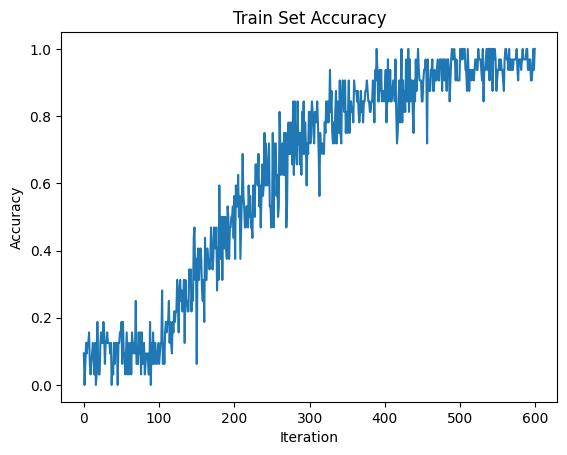

In [3]:
# Plot Loss
fig = plt.figure(facecolor="w")
plt.plot(acc_hist)
plt.title("Train Set Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.show()

In [4]:
# Make sure your model is in evaluation mode
scnn_net.eval()

# Initialize variables to store predictions and ground truth labels
acc_hist = []

# Iterate over batches in the testloader
with torch.no_grad():
    for data, targets in testloader:
        # Move data and targets to the device (GPU or CPU)
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass
        spk_rec = forward_pass(scnn_net, data)

        acc = SF.accuracy_rate(spk_rec, targets)
        acc_hist.append(acc)

        # if i%10 == 0:
        # print(f"Accuracy: {acc * 100:.2f}%\n")

print("The average loss across the testloader is:", statistics.mean(acc_hist))

The average loss across the testloader is: 0.6375


The target label is: 9


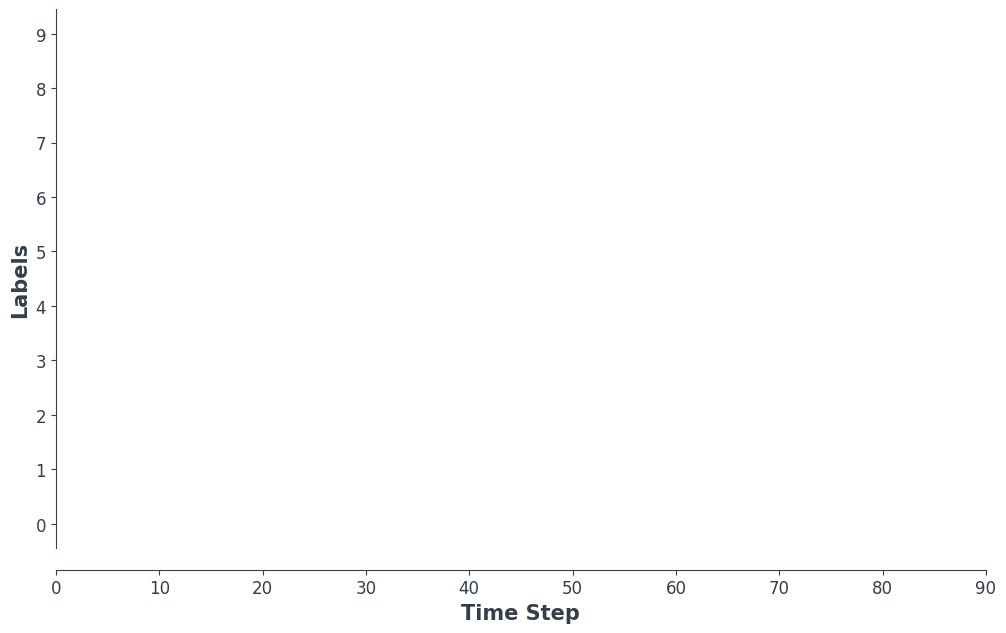

In [6]:
spk_rec = forward_pass(scnn_net, data)

# Change index to visualize a different sample
idx = 0
fig, ax = plt.subplots(facecolor='w', figsize=(12, 7))
labels=['0', '1', '2', '3', '4', '5', '6', '7', '8','9']
print(f"The target label is: {targets[idx]}")

#  Plot spike count histogram
anim = splt.spike_count(spk_rec[:, idx].detach().cpu(), fig, ax, labels=labels,
                        animate=True, interpolate=1)

display(HTML(anim.to_html5_video()))
# anim.save("spike_bar.mp4")